# Deep Learning

### Assignment-3: Sentence Embeddings for Sanskrit–English
#### Name: Krishnendu Halder
#### Roll: G25AIT1077

In [ ]:
# Required Dependencies
! pip install -U sentence-transformers pandas scikit-learn matplotlib

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

## Dataset
The data is represented by an aligned Sanskrit and English sentence. 
The training split (train_sa.csv and train_en.csv) was utilized and concatenated with the help of Source id.

In [4]:
# load training datasets

train_data_sa = pd.read_csv("./data/train_sa_10000.csv")
train_data_en = pd.read_csv("./data/train_en_10000.csv")

# merge with source_id

dataFrame = pd.merge(train_data_sa, train_data_en, on='Source_id')
dataFrame.head()

,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


## Model

A pretrained multilingual Sentence Transformer model is used by us. 
The model to produce sentence embeddings is (paraphrase-multilingual-MiniLM-L12-v2).

In [5]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6533.18it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Results

- Embedding Dimension: 384
- Average Cosine Similarity: ~0.55

In [6]:
sa_sentence_list = dataFrame['Sentence_sa'].tolist()
en_sentence_list = dataFrame['Sentence_en'].tolist()

sa_enbedding_data = model.encode(sa_sentence_list)
en_enbedding_data = model.encode(en_sentence_list)

print("Embedding shape of Sanskrit:", sa_enbedding_data.shape)
print("Embedding shape of English:", en_enbedding_data.shape)


cosine_similarity_matrix = cosine_similarity(sa_enbedding_data, en_enbedding_data)
similarity_diagonal = cosine_similarity_matrix.diagonal()
avarage_similarity = np.mean(similarity_diagonal)
print("Average Cosine Similarity:", avarage_similarity)

Embedding shape of Sanskrit: (10000, 384)
Embedding shape of English: (10000, 384)
Average Cosine Similarity: 0.54828054


## Visualization

t-SNE is used to reduce embeddings to 2D for visualization.

Average Cosine Similarity: 0.54828054


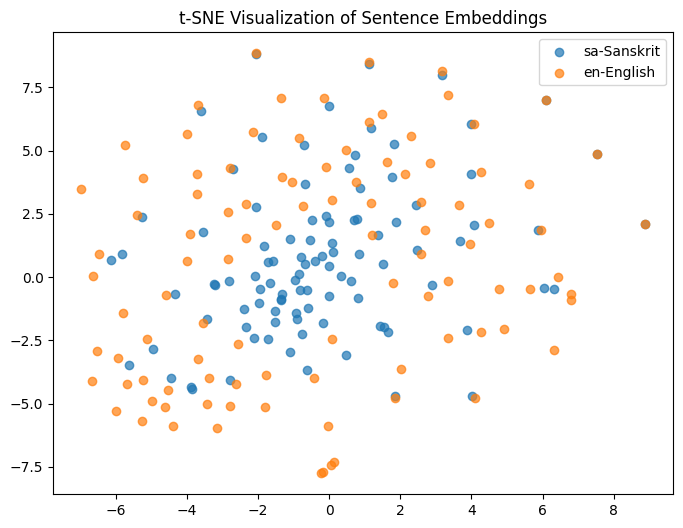

In [7]:

similarity_diagonal = cosine_similarity_matrix.diagonal()

avarage_similarity = np.mean(similarity_diagonal)
print("Average Cosine Similarity:", avarage_similarity)


# Take 100 samples
sa_embedded_sample = sa_enbedding_data[:100]
en_embedded_sample = en_enbedding_data[:100]

combined = np.vstack((sa_embedded_sample, en_embedded_sample))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(combined)

# Split back
sa_2d = reduced[:100]
en_2d = reduced[100:]

plt.figure(figsize=(8,6))

plt.scatter(sa_2d[:,0], sa_2d[:,1], label="sa-Sanskrit", alpha=0.7)
plt.scatter(en_2d[:,0], en_2d[:,1], label="en-English", alpha=0.7)

plt.legend()
plt.title("t-SNE Visualization of Sentence Embeddings")
plt.show()

## Conclusion

The model depicts moderate cross-lingual correspondence of Sanskrit and English sentences.